In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=15
)

In [4]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
lr = LinearRegression()

In [6]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
lr_pred = lr.predict(X_test)

In [8]:
print("Linear Regression")
print("MSE :", mean_squared_error(y_test, lr_pred))
print("R2  :", r2_score(y_test, lr_pred))

Linear Regression
MSE : 0.5274797591003858
R2  : 0.607459461445574


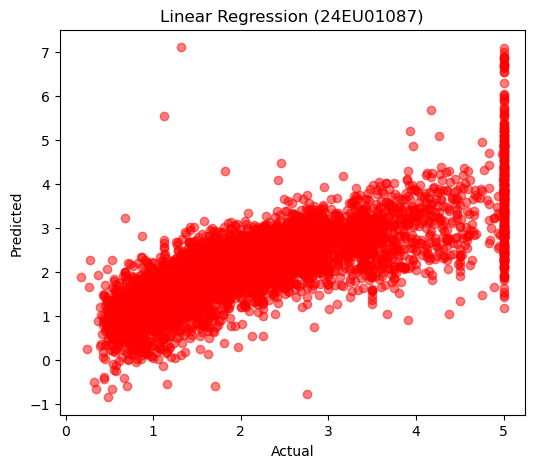

In [9]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, lr_pred, color="red", alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression (24EU01087)")

plt.show()

In [10]:
dt = DecisionTreeRegressor(max_depth=10, random_state=15)

In [11]:
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,15
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [12]:
dt_pred = dt.predict(X_test)

In [13]:
print("\nDecision Tree")

print("MSE :", mean_squared_error(y_test, dt_pred))
print("R2  :", r2_score(y_test, dt_pred))


Decision Tree
MSE : 0.4406128078899612
R2  : 0.6721042164763195


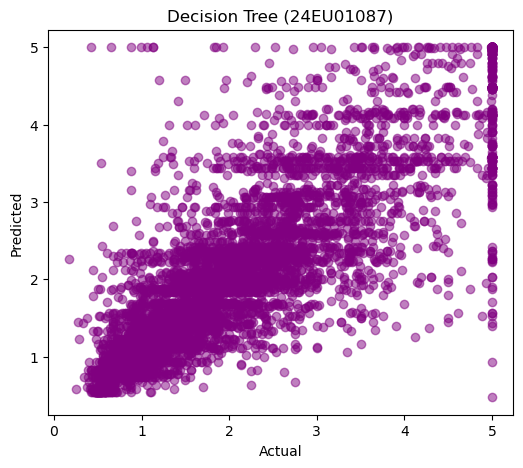

In [14]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, dt_pred, color="purple", alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree (24EU01087)")

plt.show()

In [15]:
models = ["Linear Regression", "Decision Tree"]

scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred)
]

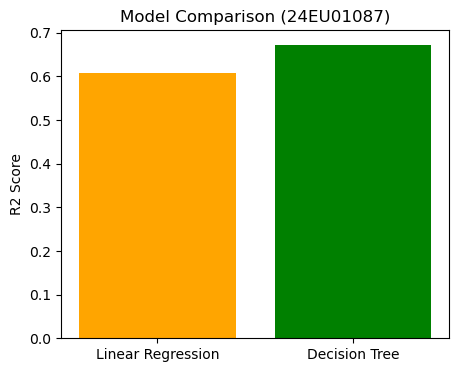

In [16]:
plt.figure(figsize=(5,4))

plt.bar(models, scores, color=["orange", "green"])

plt.ylabel("R2 Score")
plt.title("Model Comparison (24EU01087)")

plt.show()